<a href="https://colab.research.google.com/github/VrishankDesai/Ai-in-healthcare/blob/main/Diabetes_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
# ─────────────────────────────────────────
# 1. UPLOAD AND LOAD DATASET
# ─────────────────────────────────────────
from google.colab import files
uploaded = files.upload()   # A popup will appear — upload your diabetes.csv

import io
# Get the first (and likely only) uploaded file name dynamically
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Saving diabetes.csv to diabetes (2).csv
Shape: (768, 9)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [4]:
# ─────────────────────────────────────────
# 2. HANDLE MISSING VALUES
# ─────────────────────────────────────────
# 0s in these columns are biologically impossible — treat them as missing
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("\nZero counts before handling:")
print((df[cols_with_zeros] == 0).sum())

df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)
df[cols_with_zeros] = df[cols_with_zeros].fillna(df[cols_with_zeros].median())

print("\nZero counts after handling:")
print((df[cols_with_zeros] == 0).sum())


Zero counts before handling:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Zero counts after handling:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


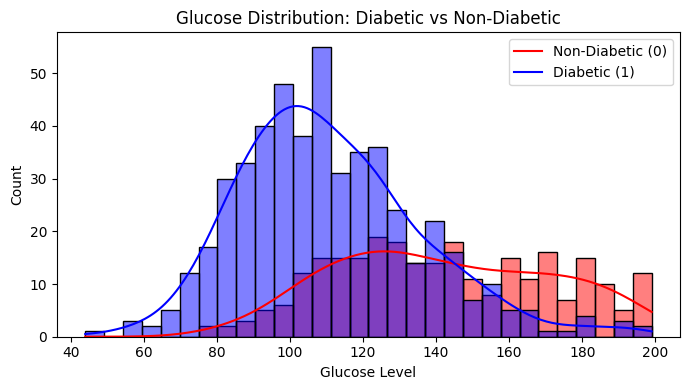

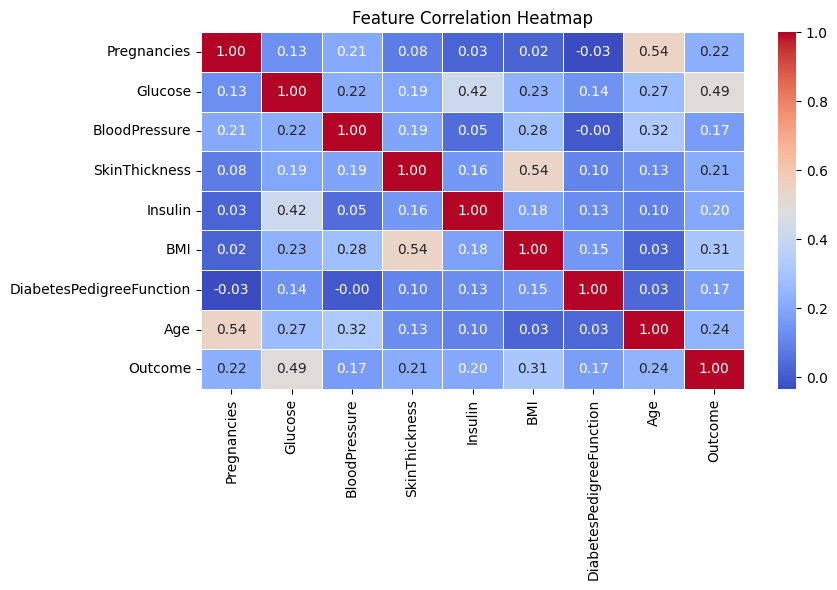

/tmp/ipykernel_9236/892390070.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome', y='BMI', palette=['lightblue', 'salmon'])


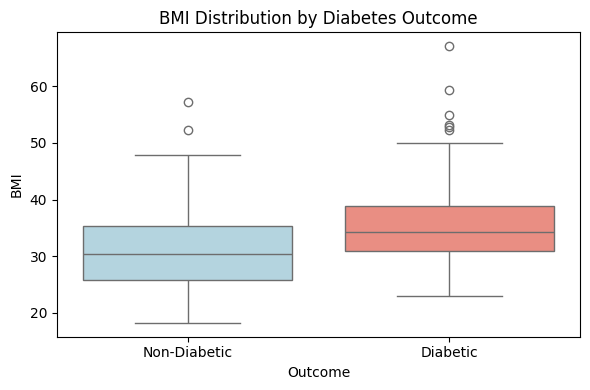

In [5]:
# ─────────────────────────────────────────
# 3. SEABORN PLOTS
# ─────────────────────────────────────────

# Plot 1: Glucose Distribution by Outcome
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='Glucose', hue='Outcome', kde=True,
             palette=['blue', 'red'], bins=30)
plt.title("Glucose Distribution: Diabetic vs Non-Diabetic")
plt.xlabel("Glucose Level")
plt.legend(["Non-Diabetic (0)", "Diabetic (1)"])
plt.tight_layout()
plt.show()

# Plot 2: Correlation Heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Plot 3: BMI Boxplot by Outcome
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Outcome', y='BMI', palette=['lightblue', 'salmon'])
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'])
plt.title("BMI Distribution by Diabetes Outcome")
plt.tight_layout()
plt.show()

In [6]:
# ─────────────────────────────────────────
# 4. PREPROCESSING
# ─────────────────────────────────────────
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 614, Test size: 154


In [7]:
# ─────────────────────────────────────────
# 5. BUILD ANN
# ─────────────────────────────────────────
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8,  activation='relu'),
    Dense(1,  activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# ─────────────────────────────────────────
# 6. COMPILE AND TRAIN
# ─────────────────────────────────────────
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6594 - loss: 0.6204 - val_accuracy: 0.5968 - val_loss: 0.6726
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6594 - loss: 0.5881 - val_accuracy: 0.5968 - val_loss: 0.6477
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6594 - loss: 0.5614 - val_accuracy: 0.5968 - val_loss: 0.6317
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6594 - loss: 0.5438 - val_accuracy: 0.5968 - val_loss: 0.6142
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6649 - loss: 0.5285 - val_accuracy: 0.5968 - val_loss: 0.6022
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6630 - loss: 0.5174 - val_accuracy: 0.5968 - val_loss: 0.5925
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6757 - loss: 0.5085 - val_accuracy: 0.6290 - val_loss: 0.5841
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6920 - loss: 0.5009 - val_accuracy: 0.6613 - val_loss

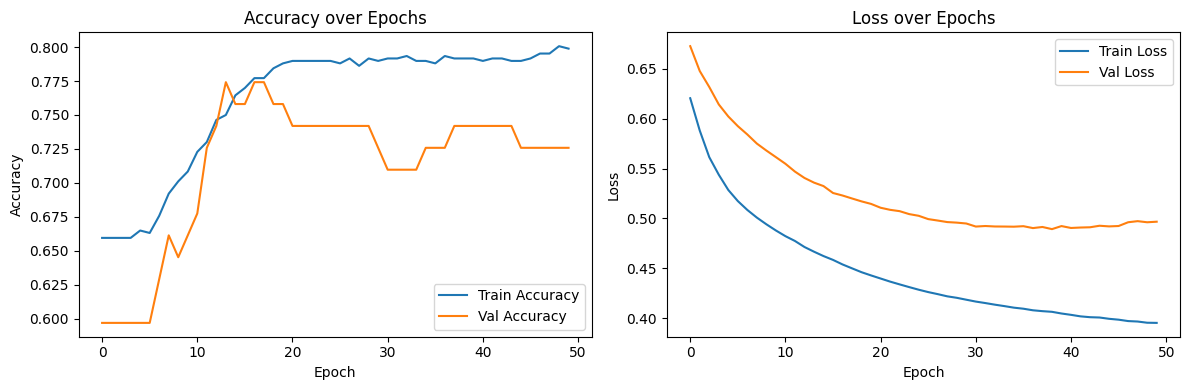

In [9]:
# ─────────────────────────────────────────
# 7. TRAINING CURVES
# ─────────────────────────────────────────
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
# ─────────────────────────────────────────
# 8. EVALUATE
# ─────────────────────────────────────────
y_pred_prob = model.predict(X_test)
y_pred      = (y_pred_prob >= 0.5).astype(int).flatten()

print("\n── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=['Non-Diabetic', 'Diabetic']))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

── Classification Report ──
              precision    recall  f1-score   support

Non-Diabetic       0.80      0.78      0.79        99
    Diabetic       0.62      0.65      0.64        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.74       154



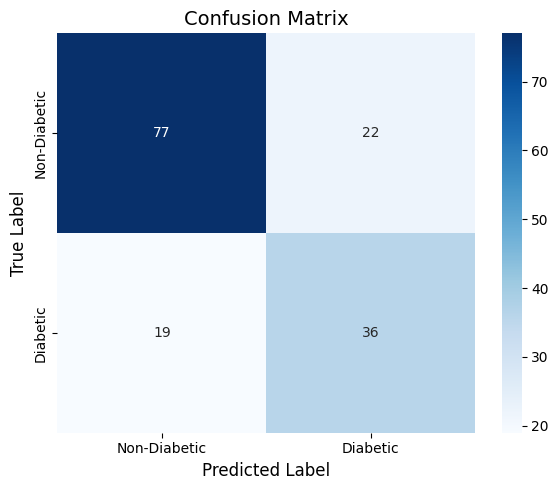

In [11]:
# ─────────────────────────────────────────
# 9. CONFUSION MATRIX
# ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()